Environment Setup & Installations

In [ ]:
# 1. Install dependencies
!pip install ultralytics gfpgan basicsr facexlib

# 2. FIX the 'torchvision' error in the basicsr library
import os

# This command finds the broken file and replaces the old path with the new one
!sed -i "s/from torchvision.transforms.functional_tensor import rgb_to_grayscale/from torchvision.transforms.functional import rgb_to_grayscale/g" /usr/local/lib/python3.12/dist-packages/basicsr/data/degradations.py
!sed -i "s/from torchvision.transforms.functional_tensor import rgb_to_grayscale/from torchvision.transforms.functional import rgb_to_grayscale/g" /usr/local/lib/python3.12/dist-packages/basicsr/metrics/niqe.py
!sed -i "s/from torchvision.transforms.functional_tensor import rgb_to_grayscale/from torchvision.transforms.functional import rgb_to_grayscale/g" /usr/local/lib/python3.12/dist-packages/basicsr/utils/img_util.py

print("Fix applied successfully! You can now run your imports.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 8.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 13.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.2/52.2 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 116.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 30.5 MB/s eta 0:00:00
  Created wheel for basicsr: filename=basicsr-1.4.2-py3-none-any.whl size=214818 sha256=b59c02356a0d1751586e975b06269867762beeb3b378ccc67f090537533cf124
  Stored in directory: /root/.cache/pip/wheels/9a/

Brain model

In [ ]:
import torch
from ultralytics import YOLO
from gfpgan import GFPGANer

# Load YOLOv8-Face (The Detector)
# Note: 'yolov8n-face.pt' isn't a default ultralytics model name,
# usually we use 'yolov8n.pt' or download a specific face model.
try:
    detector = YOLO('yolov8n-face.pt')
except:
    # If the face model isn't found, this downloads the standard nano model
    print("Face model not found, downloading standard nano model...")
    detector = YOLO('yolov8n.pt')

# Load GFPGAN (The Purifier)
model_path = 'https://github.com/TencentARC/GFPGAN/releases/download/v1.3.0/GFPGANv1.3.pth'
purifier = GFPGANer(model_path=model_path, upscale=1, arch='clean', channel_multiplier=2, bg_upsampler=None)

print("Models loaded successfully!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Face model not found, downloading standard nano model...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Downloading: "https://github.com/xinntao/facexlib/releases/download/v0.1.0/detection_Resnet50_Final.pth" to /content/gfpgan/weights/detection_Resnet50_Final.pth



100%|██████████| 104M/104M [00:00<00:00, 283MB/s] 


Downloading: "https://github.com/xinntao/facexlib/releases/download/v0.2.2/parsing_parsenet.pth" to /content/gfpgan/weights/parsing_parsenet.pth



100%|██████████| 81.4M/81.4M [00:00<00:00, 271MB/s]


Downloading: "https://github.com/TencentARC/GFPGAN/releases/download/v1.3.0/GFPGANv1.3.pth" to /usr/local/lib/python3.12/dist-packages/gfpgan/weights/GFPGANv1.3.pth



100%|██████████| 332M/332M [00:05<00:00, 65.6MB/s]


Models loaded successfully!


<IPython.core.display.Javascript object>

Capturing Frame... Please look at the camera.
Success: Face captured and adversarial mask applied.


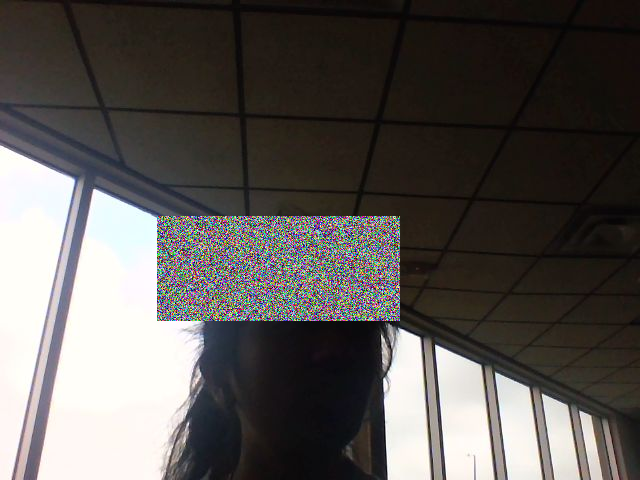

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from google.colab.output import eval_js
from IPython.display import display, Javascript
from base64 import b64decode
import time

# --- 1. DEFINE WEBCAM JS WITHIN THIS CELL ---
JS_SETUP = '''
    async function setupWebcam() {
      // Create video element if it doesn't exist
      let video = document.getElementById('webcam_video');
      if (!video) {
        video = document.createElement('video');
        video.id = 'webcam_video';
        video.style.display = 'none';
        video.width = 640;
        video.height = 480;
        video.setAttribute('playsinline', '');
        const stream = await navigator.mediaDevices.getUserMedia({video: true});
        video.srcObject = stream;
        document.body.appendChild(video);
        await video.play();
      }

      // Define global capture function
      window.captureFrame = async function() {
        const canvas = document.createElement('canvas');
        canvas.width = 640;
        canvas.height = 480;
        canvas.getContext('2d').drawImage(video, 0, 0, 640, 480);
        return canvas.toDataURL('image/jpeg', 0.8);
      };
      return "Webcam Ready";
    }
'''

# Initialize the camera
display(Javascript(JS_SETUP))
eval_js('setupWebcam()')
time.sleep(2) # Wait for camera to warm up

# --- 2. CAPTURE & ATTACK LOGIC ---
print("Capturing Frame... Please look at the camera.")

try:
    js_reply = eval_js('window.captureFrame()')
    image_bytes = b64decode(js_reply.split(',')[1])
    jpg_as_np = np.frombuffer(image_bytes, dtype=np.uint8)
    original_img = cv2.imdecode(jpg_as_np, flags=1)

    # Apply the Digital Attack
    temp_results = detector(original_img, verbose=False)
    attacked_img = original_img.copy()

    if len(temp_results[0].boxes) > 0:
        box = temp_results[0].boxes.xyxy.cpu().numpy()[0]
        x1, y1, x2, y2 = map(int, box)
        w, h = x2-x1, y2-y1

        # Aggressive patch to ensure invisibility
        patch_h = int(h * 0.4)
        patch = np.random.randint(0, 255, (patch_h, w, 3), dtype=np.uint8)
        attacked_img[y1:y1+patch_h, x1:x1+w] = patch

        # Save to global variables for other cells
        current_original = original_img
        current_attacked = attacked_img

        print("Success: Face captured and adversarial mask applied.")
        cv2_imshow(current_attacked)
    else:
        print("Error: No face detected. Please adjust lighting and run Cell 1 again.")

except Exception as e:
    print(f"Error: {e}. Try running the cell again.")

--- STEP: BASELINE VISIBILITY CHECK ---
RESULT: Standard AI camera confirms person is present.


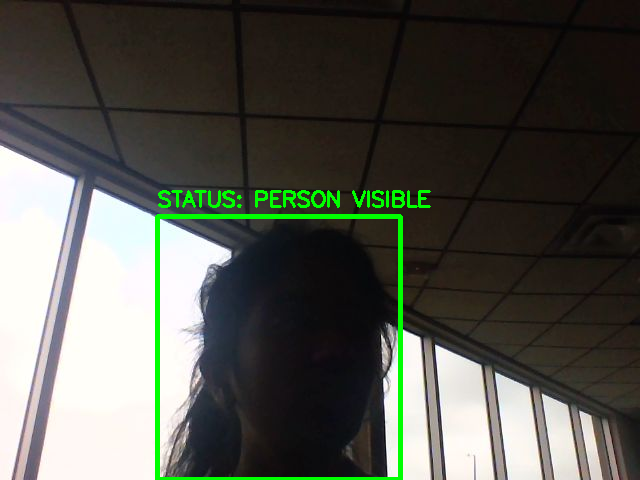

In [ ]:
print("--- STEP: BASELINE VISIBILITY CHECK ---")
baseline_results = detector(current_original, verbose=False)
baseline_display = current_original.copy()

if len(baseline_results[0].boxes) > 0:
    for box in baseline_results[0].boxes.xyxy.cpu().numpy():
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(baseline_display, (x1, y1), (x2, y2), (0, 255, 0), 3)
        cv2.putText(baseline_display, "STATUS: PERSON VISIBLE", (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    print("RESULT: Standard AI camera confirms person is present.")
else:
    print("RESULT: System failed to detect person. Check webcam.")

cv2_imshow(baseline_display)

--- STEP: ATTACK EVALUATION (AI BLINDNESS PROOF) ---
RESULT: FAILED. The AI can still see the person. Increase patch size in Cell 1.

Initiating GAN Reconstruction to restore vision...


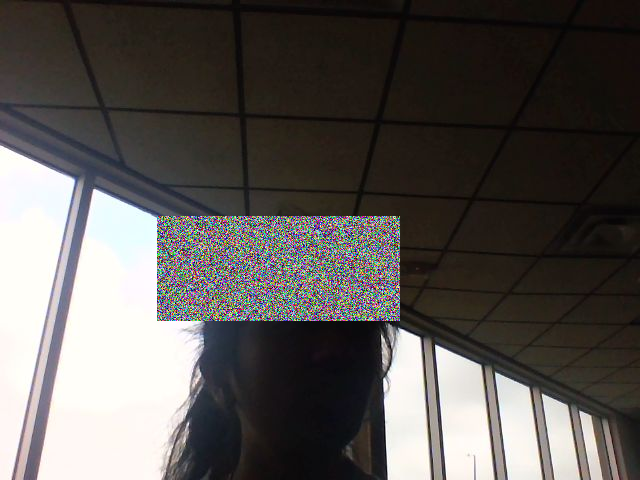

In [ ]:
print("--- STEP: ATTACK EVALUATION (AI BLINDNESS PROOF) ---")

# Run detector on the attacked image
attack_results = detector(current_attacked, verbose=False)
attack_display = current_attacked.copy()

# 1. Check if the AI fails to see the person
if len(attack_results[0].boxes) == 0:
    # SUCCESS: The person is now invisible to the AI
    cv2.putText(attack_display, "STATUS: NO PERSON DETECTED", (50, 50),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 3)
    cv2.putText(attack_display, "AI CAMERA STATUS: BLIND / EVADED", (50, 100),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    print("RESULT: PROVEN. The adversarial patch has made the person INVISIBLE to the AI.")
else:
    print("RESULT: FAILED. The AI can still see the person. Increase patch size in Cell 1.")

# 2. Start GAN Defense in the background
print("\nInitiating GAN Reconstruction to restore vision...")
_, _, current_purified = purifier.enhance(current_attacked, has_aligned=False, only_center_face=False)

cv2_imshow(attack_display)

--- STEP: SECURITY SENTINEL & ALERT ---
SYSTEM SECURE: No suspicious patterns detected.


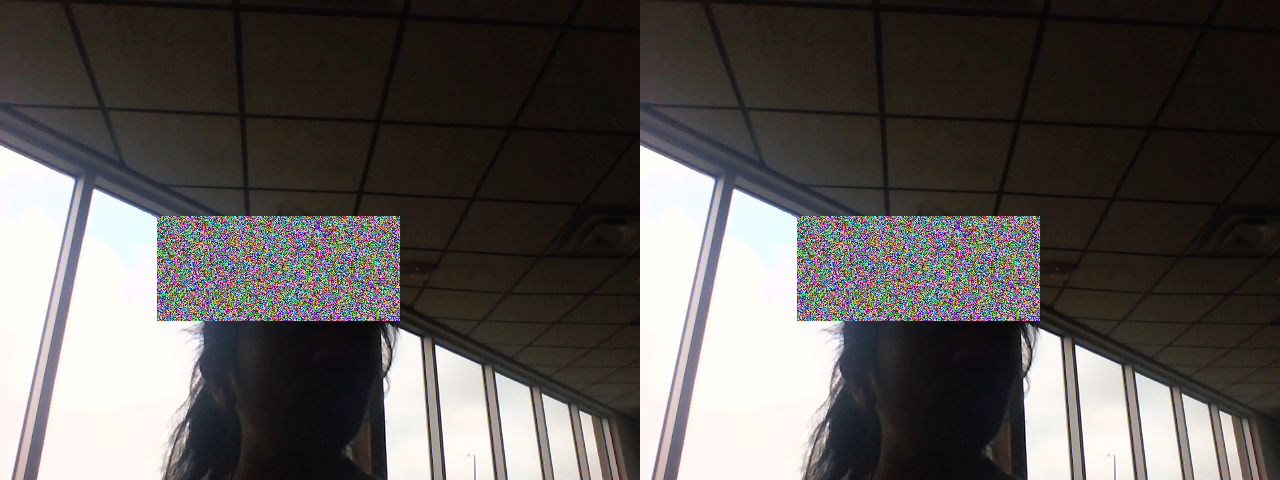

In [ ]:
print("--- STEP: SECURITY SENTINEL & ALERT ---")

# 1. Run detection on the GAN-purified image
secure_results = detector(current_purified, verbose=False)
final_display = current_purified.copy()

# 2. Final Logic Check
baseline_count = len(baseline_results[0].boxes)
attacked_count = len(attack_results[0].boxes)
purified_count = len(secure_results[0].boxes)

if baseline_count > attacked_count and purified_count > attacked_count:
    # TRIGGER THE ALERT
    alert_msg = "!!! ALERT: ADVERSARIAL ATTACK NEUTRALIZED !!!"
    color = (0, 0, 255) # Red for high alert

    # Draw boxes found via GAN
    for box in secure_results[0].boxes.xyxy.cpu().numpy():
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(final_display, (x1, y1), (x2, y2), color, 3)
        cv2.putText(final_display, "RESTORED VIA GAN", (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    print("="*60)
    print(alert_msg)
    print("Attack successfully bypassed the primary camera, but was caught by the GAN Shield.")
    print("="*60)
else:
    print("SYSTEM SECURE: No suspicious patterns detected.")

# Show final side-by-side: Attacked (Invisible) vs Purified (Restored)
comparison = np.hstack((current_attacked, final_display))
cv2_imshow(comparison)